In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, accuracy_score

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Copy of loan.csv')

# Data Preprocessing




In [ ]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
cat = df.select_dtypes(include = ['object']).columns
cat=cat.drop('Loan_ID')
cat.to_list()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [ ]:
for col in cat:
  print(f'{col}: {df[col].unique()}')

Gender: ['Male' 'Female' nan]
Married: ['No' 'Yes' nan]
Dependents: ['0' '1' '2' '3+' nan]
Education: ['Graduate' 'Not Graduate']
Self_Employed: ['No' 'Yes' nan]
Property_Area: ['Urban' 'Rural' 'Semiurban']
Loan_Status: ['Y' 'N']


In [ ]:
df.describe(include='number')

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
num = df.select_dtypes(include = ['number']).columns
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

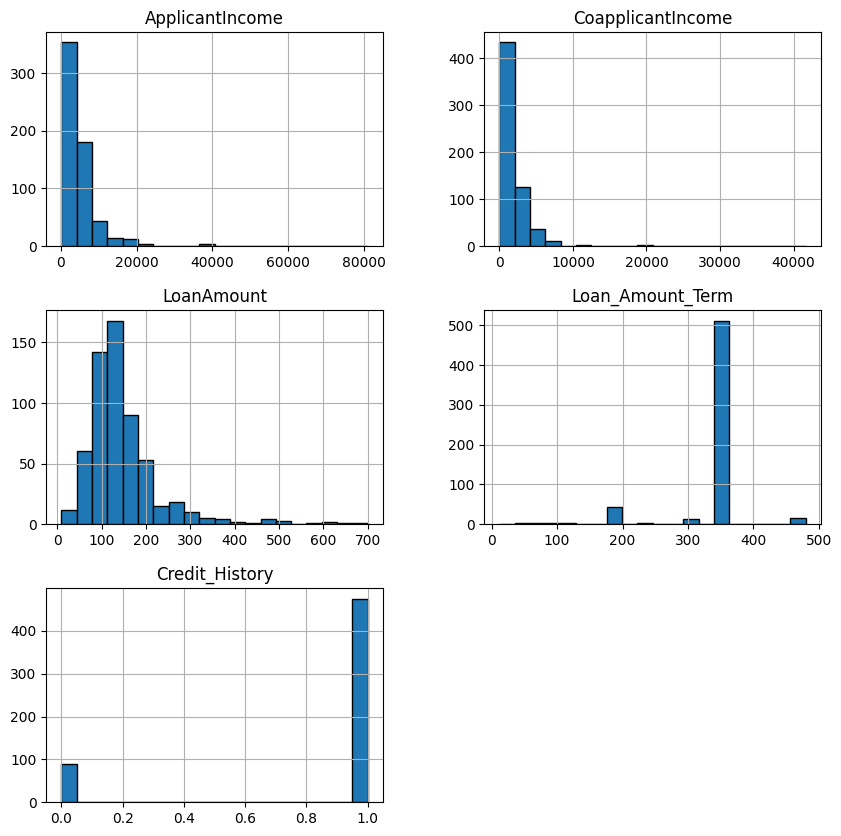

In [ ]:
df.hist(bins=20,edgecolor='black',figsize=(10,10))
plt.show()

**Handling skewness**

In [ ]:
# Create log-transformed features for skewed distributions
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)  # Added +1 to handle zeros
df['ApplicantIncome_log'] = np.log(df['ApplicantIncome'] + 1)

# Create total income features
df['totalincome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['totalincome_log'] = np.log(df['totalincome'] + 1)

## Data cleansing

In [ ]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical columns with MEAN
for col in ['LoanAmount', 'LoanAmount_log', 'Loan_Amount_Term', 'Credit_History']:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())


Missing Values After Cleaning:
 Loan_ID                0
Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount             0
Loan_Amount_Term       0
Credit_History         0
Property_Area          0
Loan_Status            0
LoanAmount_log         0
ApplicantIncome_log    0
totalincome            0
totalincome_log        0
dtype: int64


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# EDA

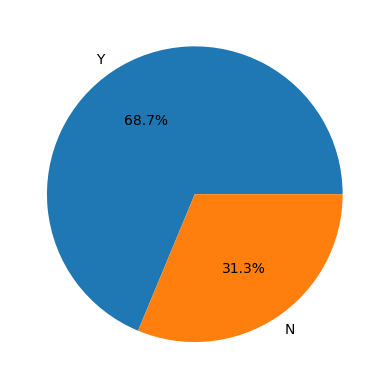

In [ ]:
temp = df['Loan_Status'].value_counts()
plt.pie(temp.values,
        labels=temp.index,
        autopct='%1.1f%%')
plt.show()

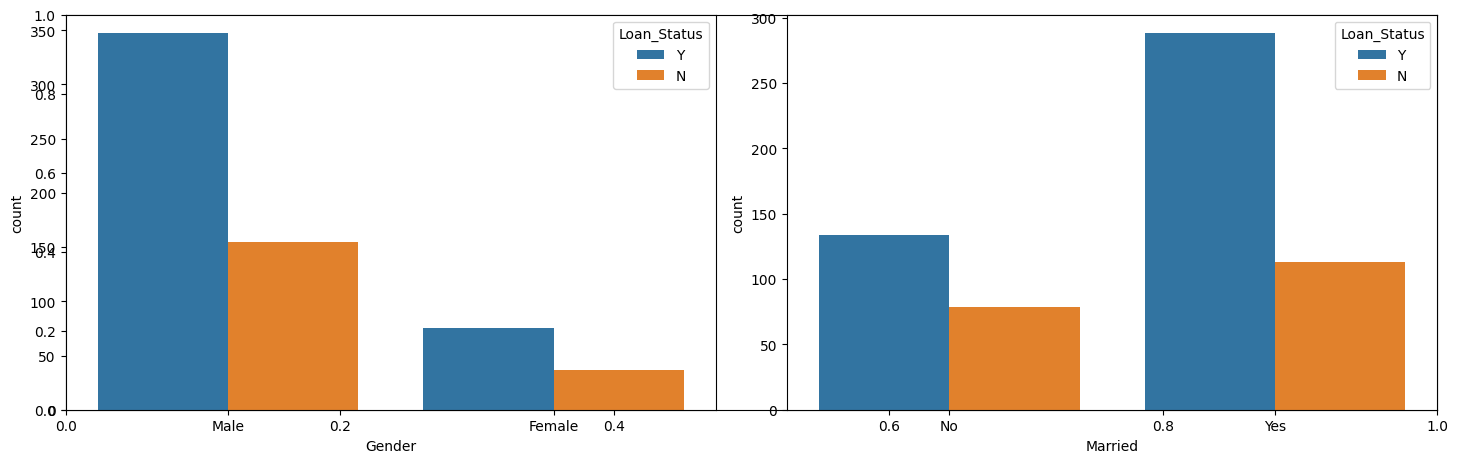

In [ ]:
plt.subplots(figsize=(15, 5))
for i, col in enumerate(['Gender', 'Married']):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df, x=col, hue='Loan_Status')
plt.tight_layout()
plt.show()

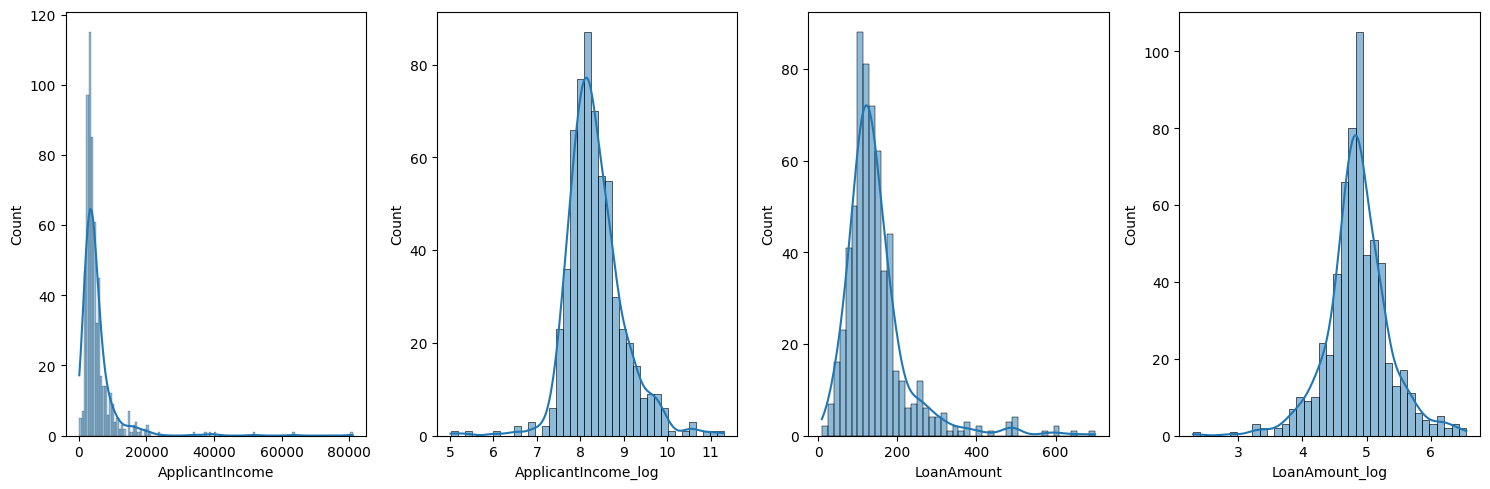

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['ApplicantIncome','ApplicantIncome_log' ,'LoanAmount', 'LoanAmount_log']):
    plt.subplot(1, 4, i+1)
    sns.histplot(df[col], kde=True)

plt.tight_layout()
plt.show()


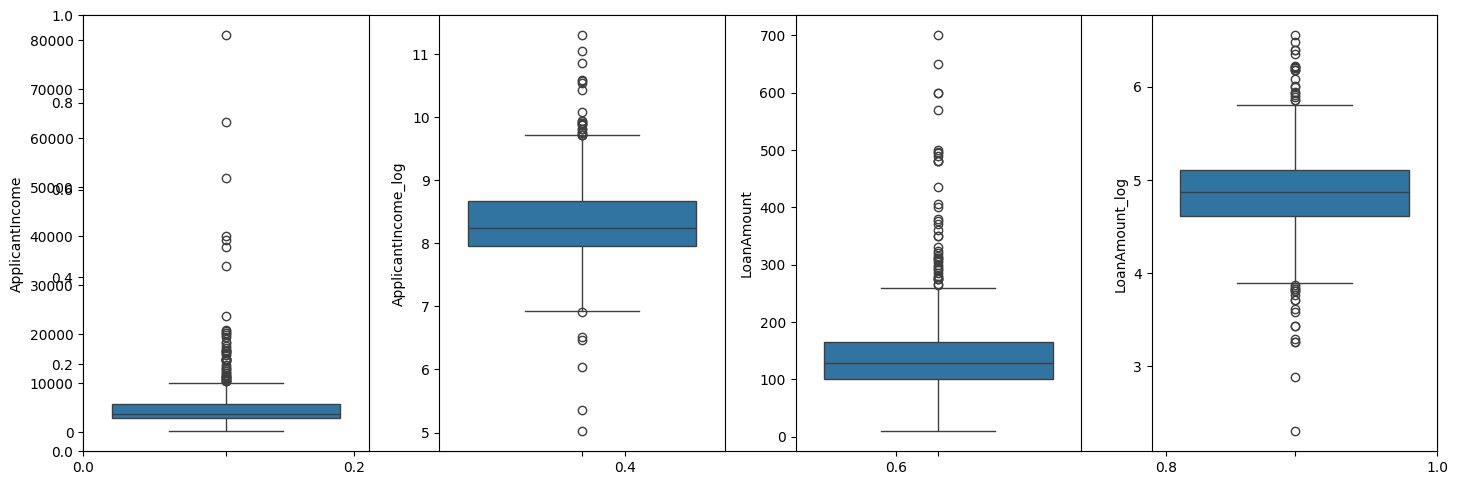

In [ ]:
plt.subplots(figsize=(15, 5))
for i, col in enumerate(['ApplicantIncome','ApplicantIncome_log' ,'LoanAmount', 'LoanAmount_log']):
    plt.subplot(1, 4, i+1)
    sns.boxplot(df[col])
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('Gender').mean(numeric_only=True)['LoanAmount']

,LoanAmount
Gender,
Female,127.225326
Male,150.692891


In [ ]:
df.groupby(['Married', 'Gender']).mean(numeric_only=True)['LoanAmount']

Married  Gender
No       Female    116.872804
         Male      137.030532
Yes      Female    153.106630
         Male      155.617264
Name: LoanAmount, dtype: float64

# Encoding & Splitting

In [ ]:
cat

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
le = LabelEncoder()
for col in cat:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'LoanAmount_log', 'ApplicantIncome_log', 'totalincome',
       'totalincome_log'],
      dtype='object')

In [ ]:
features = df.drop(['Loan_Status', 'Loan_ID','ApplicantIncome','LoanAmount','totalincome'], axis=1)

In [ ]:
target_encoder = LabelEncoder()

target = target_encoder.fit_transform(df['Loan_Status'])

print("Feature shape:", features.shape)

Feature shape: (614, 12)


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target)

print(f"\nTraining set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Class distribution in training: {np.bincount(Y_train)}")


Training set size: (491, 12)
Validation set size: (123, 12)
Class distribution in training: [154 337]


 **Bonus - SMOTE**

In [ ]:
# Handling IMBALANCE
# sm = SMOTE(sampling_strategy='minority', random_state=42)
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, Y_resampled = sm.fit_resample(X_train, Y_train)

print(f"\nAfter SMOTE - Training set size: {X_resampled.shape}")
print(f"Class distribution after SMOTE: {np.bincount(Y_resampled)}")


After SMOTE - Training set size: (674, 12)
Class distribution after SMOTE: [337 337]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_resampled)
X_val_scaled = scaler.transform(X_val)

# Model Development

## SVM

In [ ]:
# model = SVC(kernel='rbf', probability=True, random_state=42)
model=SVC( kernel='rbf', probability=True, random_state=42,class_weight='balanced',C=1.0)

In [ ]:
model.fit(X_train_scaled, Y_resampled)

SVC(class_weight='balanced', probability=True, random_state=42)

In [ ]:
# Get predictions
Y_train_pred = model.predict(X_train_scaled)
Y_val_pred = model.predict(X_val)

In [ ]:
train_accuracy = metrics.accuracy_score(Y_resampled, Y_train_pred)
val_accuracy = metrics.accuracy_score(Y_val, Y_val_pred)
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

Training Accuracy: 0.8116
Validation Accuracy: 0.8211


In [ ]:
# Confusion Matrix
cm = confusion_matrix(Y_val, Y_val_pred)
print(cm)

[[24 14]
 [ 8 77]]


## Decision Tree - Bonus

In [ ]:
model=DecisionTreeClassifier(random_state=42, max_depth=5,class_weight='balanced',
                       min_samples_split=10,min_samples_leaf=5)

In [ ]:
model.fit(X_train_scaled, Y_resampled)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [ ]:
# Get predictions
Y_train_pred = model.predict(X_train_scaled)
Y_val_pred = model.predict(X_val)

In [ ]:
train_accuracy = metrics.accuracy_score(Y_resampled, Y_train_pred)
val_accuracy = metrics.accuracy_score(Y_val, Y_val_pred)
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

Training Accuracy: 0.7997
Validation Accuracy: 0.8537


In [ ]:
# Confusion Matrix
cm = confusion_matrix(Y_val, Y_val_pred)
print(cm)

[[21 17]
 [ 1 84]]
